# Pedestrians intention detection

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import os
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


# Load the Data

In [ ]:
%%capture
!pip install pafy

In [ ]:
%%capture
import os
import cv2
# import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model





In [ ]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/annotations.csv")
df.head()

,image,class_id,x_center,y_center,width,height
0,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,1,0.356250,0.447656,0.215625,0.276562
1,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.428906,0.428906,0.032031,0.198437
2,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.309375,0.435937,0.032031,0.160938
3,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.336719,0.432812,0.030469,0.158594
4,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.360938,0.438281,0.029687,0.173437


In [ ]:
# Define class names
classes = {
    0: 'walking',
    1: 'walking group',
    2: 'standing',
    3: 'crossing'
}

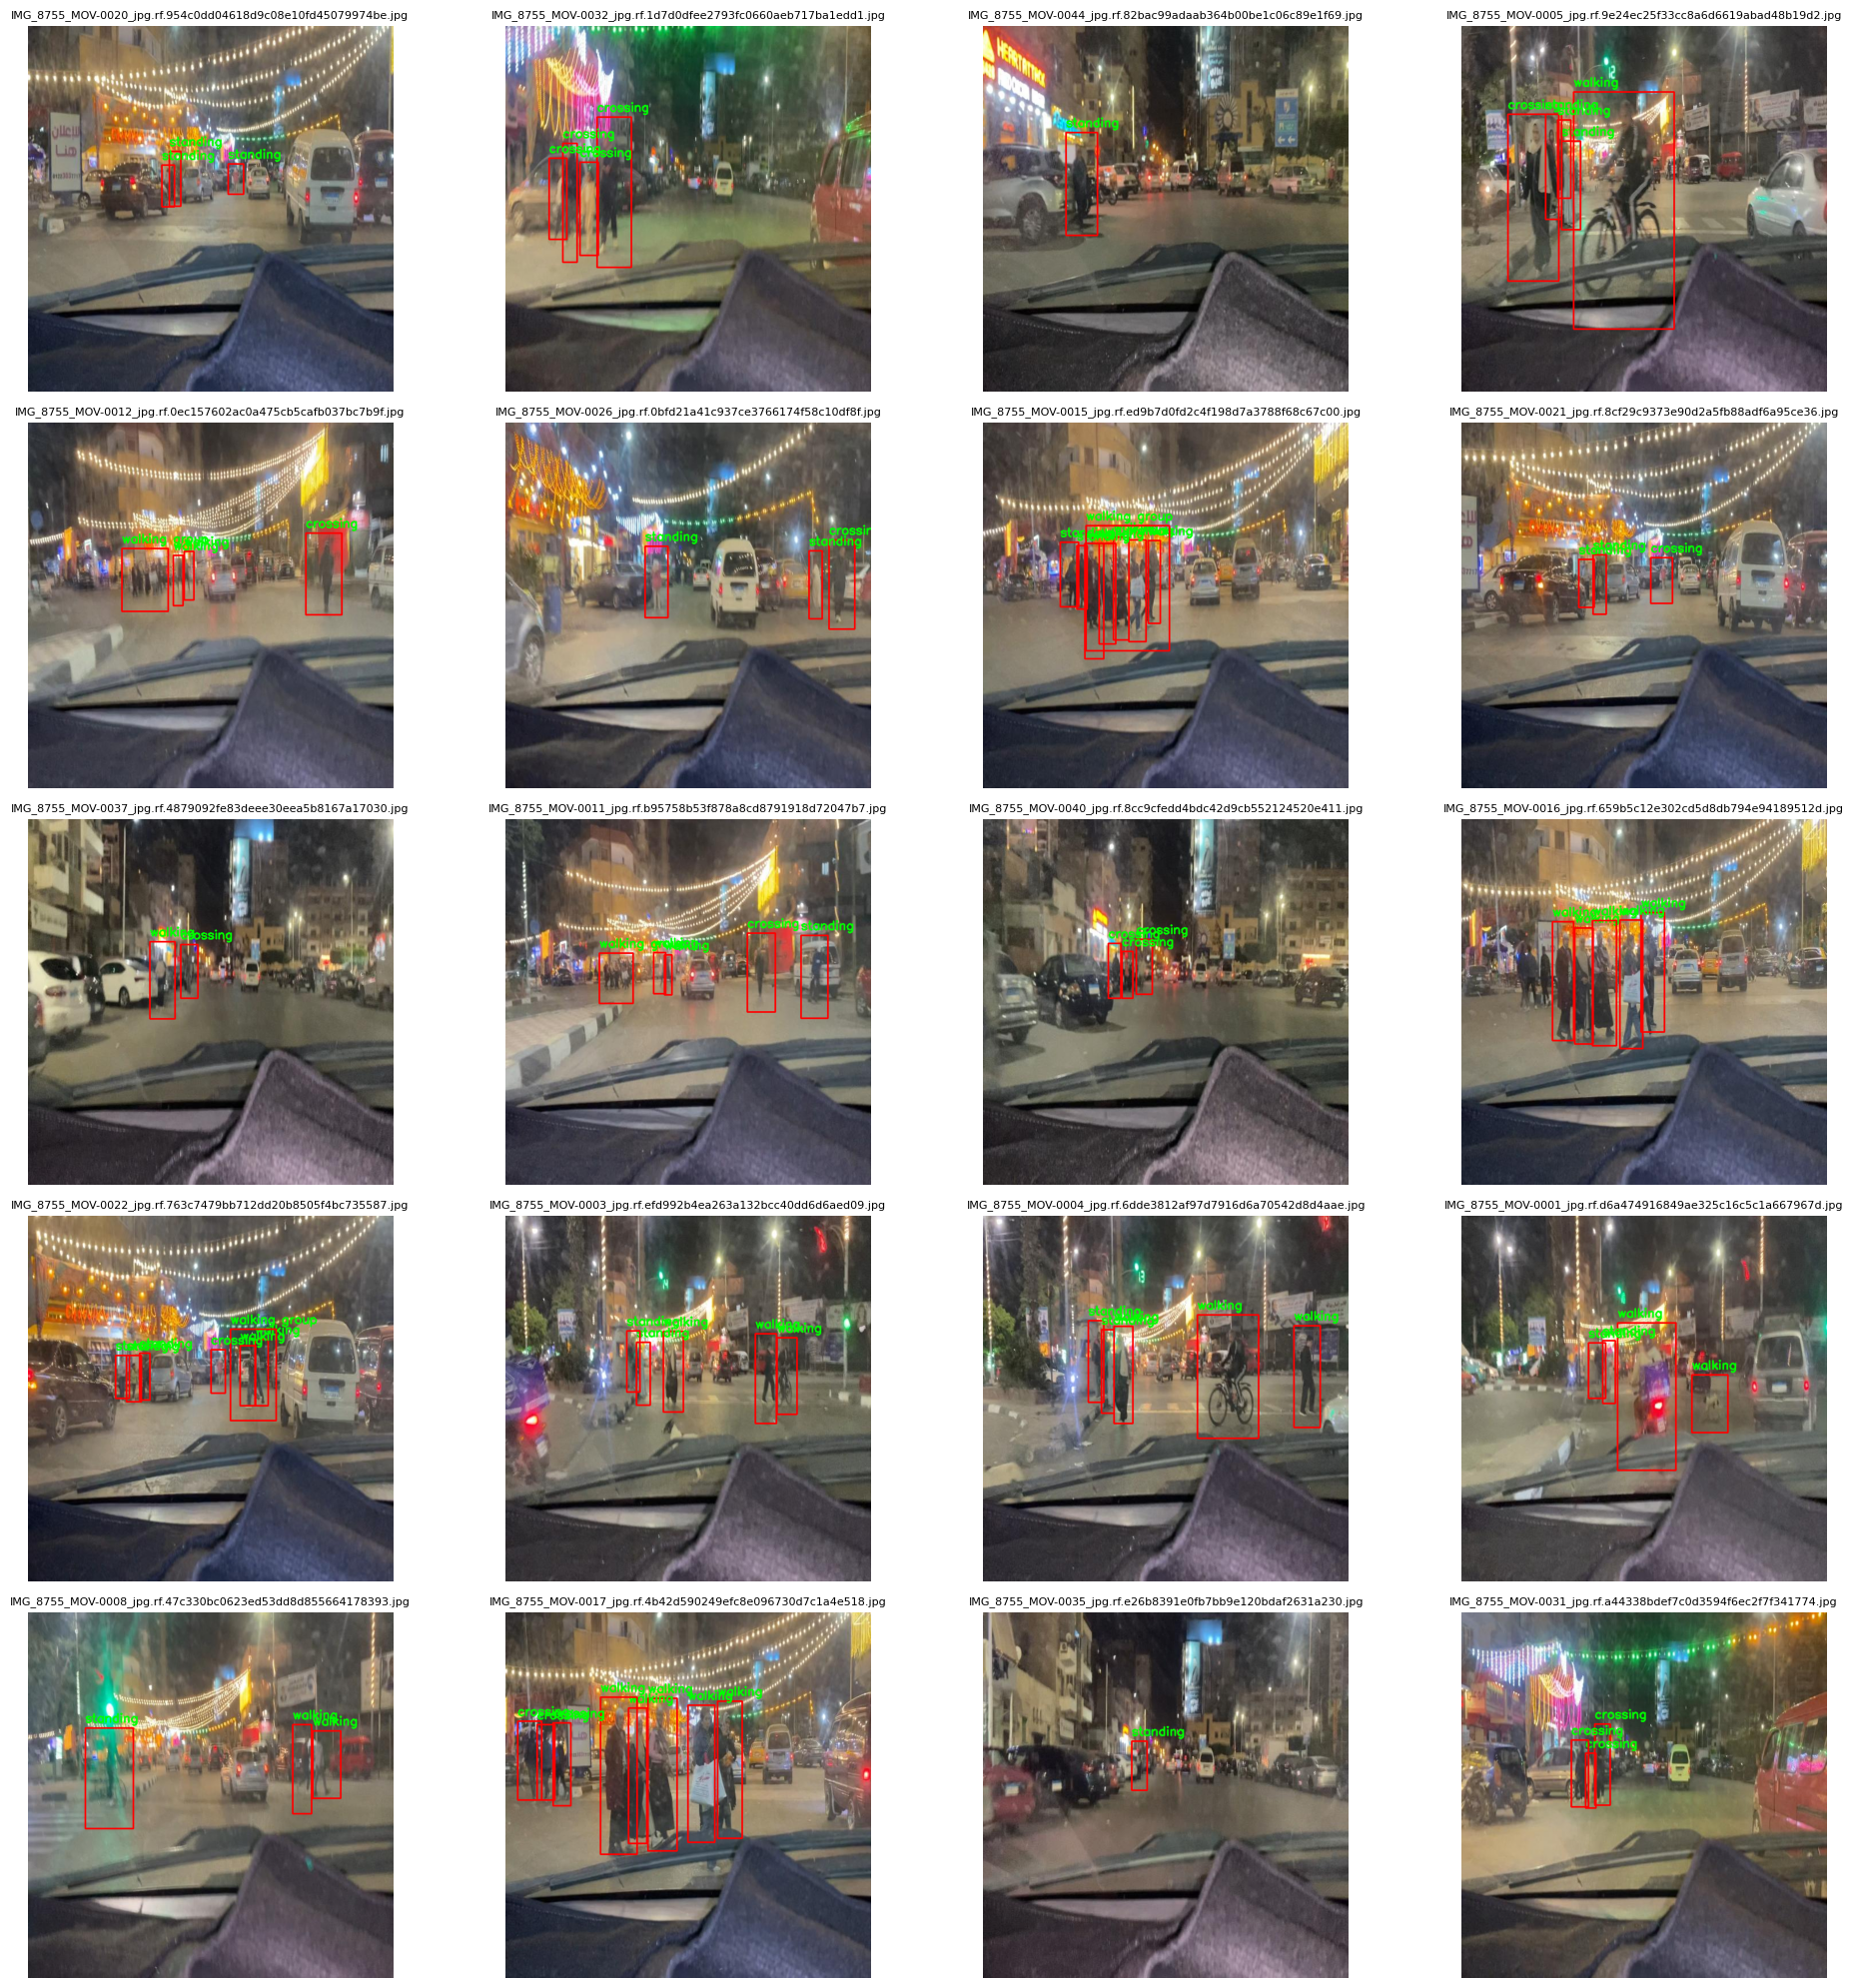

In [ ]:
# Get 20 random unique image names
random_images = df['image'].unique()
selected_images = random.sample(list(random_images), 20)

# Create a Matplotlib figure
plt.figure(figsize=(20, 20))

# Iterate through selected images
for idx, image_name in enumerate(selected_images, 1):

    # Get all rows corresponding to this image
    image_data = df[df['image'] == image_name]

    # Construct image path
    image_path = os.path.join('/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/train/images', image_name)  # adjust folder name

    # Check if image exists
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        continue

    # Read and convert image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to read image: {image_path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Draw all bounding boxes for the current image
    for _, row in image_data.iterrows():
        class_id = int(row['class_id'])
        class_name = classes.get(class_id, 'Unknown')

        x_center, y_center = row['x_center'], row['y_center']
        box_width, box_height = row['width'], row['height']

        # Convert normalized coordinates to pixel values
        x1 = int((x_center - box_width / 2) * w)
        y1 = int((y_center - box_height / 2) * h)
        x2 = int((x_center + box_width / 2) * w)
        y2 = int((y_center + box_height / 2) * h)

        # Draw bounding box and class name
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, class_name, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Display image with annotations
    plt.subplot(5, 4, idx)
    plt.imshow(img)
    plt.title(image_name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Group sequence

In [ ]:
import os
import pandas as pd

# Define your paths
labels_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/train/labels"
images_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/train/images"

all_annotations = []

for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        image_name = label_file.replace(".txt", ".jpg")  # or .png if needed
        with open(os.path.join(labels_path, label_file), "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
                all_annotations.append({
                    "image": image_name,
                    "class_id": class_id,
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height
                })

# Convert to DataFrame
df = pd.DataFrame(all_annotations)

In [ ]:
df.head()

,image,class_id,x_center,y_center,width,height
0,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,1,0.356250,0.447656,0.215625,0.276562
1,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.428906,0.428906,0.032031,0.198437
2,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.309375,0.435937,0.032031,0.160938
3,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.336719,0.432812,0.030469,0.158594
4,IMG_8755_MOV-0014_jpg.rf.f6fb42ada74d0babcc1f8...,0,0.360938,0.438281,0.029687,0.173437


In [ ]:
# Define class names
classes_list = {
    0: 'walking',
    1: 'walking group',
    2: 'standing',
    3: 'crossing'
}

In [ ]:
# import os
# import cv2
# import numpy as np
# import pandas as pd

# SEQUENCE_LENGTH = 5  # or however many frames per sequence you want

# def create_lstm_sequences():
#     features = []
#     labels = []
#     image_files_paths = []

#     for class_index, class_name in enumerate(classes_list):
#         print(f'Processing class: {class_name}')
#         class_data = df[df['class_id'] == class_index]

#         # Check if there is any data for this class
#         if class_data.empty:
#             print(f'No data found for class {class_name}. Skipping.')
#             continue

#         # Group by track_id or image name (assuming you have a track_id or some way to identify the same person across frames)
#         for track_id, group in class_data.groupby('track_id'):
#             # Sort by frame (if necessary)
#             group = group.sort_values(by='frame')

#             # Check if we have enough frames to form a sequence
#             if len(group) >= SEQUENCE_LENGTH:
#                 sequence_frames = []
#                 for _, row in group.iterrows():
#                     image_name = row['image']
#                     image_path = os.path.join('/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/train/images', image_name)

#                     if not os.path.exists(image_path):
#                         print(f'Image {image_name} does not exist. Skipping.')
#                         continue

#                     img = cv2.imread(image_path)
#                     if img is None:
#                         print(f'Failed to load image {image_name}. Skipping.')
#                         continue

#                     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#                     h, w, _ = img.shape

#                     # Get the bounding box of the current person/object (tracked by track_id)
#                     x_center, y_center = row['x_center'], row['y_center']
#                     box_width, box_height = row['width'], row['height']

#                     x1 = int((x_center - box_width / 2) * w)
#                     y1 = int((y_center - box_height / 2) * h)
#                     x2 = int((x_center + box_width / 2) * w)
#                     y2 = int((y_center + box_height / 2) * h)

#                     x1, y1 = max(x1, 0), max(y1, 0)
#                     x2, y2 = min(x2, w), min(y2, h)

#                     cropped = img[y1:y2, x1:x2]
#                     processed = preprocess_cropped_frame(cropped)  # Assuming this function processes the cropped image
#                     sequence_frames.append(processed)

#                 # Add the full sequence if it has enough frames
#                 if len(sequence_frames) >= SEQUENCE_LENGTH:
#                     # You can slide window or just take fixed sequences
#                     for i in range(0, len(sequence_frames) - SEQUENCE_LENGTH + 1):
#                         seq = sequence_frames[i:i + SEQUENCE_LENGTH]
#                         features.append(seq)
#                         labels.append(class_index)
#                         image_files_paths.append(image_path)

#     # Convert to arrays
#     features = np.asarray(features)  # shape: (num_sequences, sequence_length, H, W, C)
#     labels = np.asarray(labels)

#     print(f'Total number of sequences: {len(features)}')

#     return features, labels, image_files_paths


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

SEQUENCE_LENGTH = 5  # Number of frames per sequence

def create_lstm_sequences():
    features = []
    labels = []
    image_files_paths = []

    for class_index, class_name in enumerate(classes_list):
        print(f'Processing class: {class_name}')
        class_data = df[df['class_id'] == class_index]

        # Check if there is any data for this class
        if class_data.empty:
            print(f'No data found for class {class_name}. Skipping.')
            continue

        # Group by image name instead of track_id
        for image_name, group in class_data.groupby('image'):
            image_path = os.path.join('/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/train/images', image_name)

            if not os.path.exists(image_path):
                print(f'Image {image_name} does not exist. Skipping.')
                continue

            img = cv2.imread(image_path)
            if img is None:
                print(f'Failed to load image {image_name}. Skipping.')
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape

            sequence_frames = []

            # Extract frames based on the data related to the image
            for _, row in group.iterrows():
                x_center, y_center = row['x_center'], row['y_center']
                box_width, box_height = row['width'], row['height']

                x1 = int((x_center - box_width / 2) * w)
                y1 = int((y_center - box_height / 2) * h)
                x2 = int((x_center + box_width / 2) * w)
                y2 = int((y_center + box_height / 2) * h)

                x1, y1 = max(x1, 0), max(y1, 0)
                x2, y2 = min(x2, w), min(y2, h)

                cropped = img[y1:y2, x1:x2]
                processed = preprocess_cropped_frame(cropped)  # Assuming this function processes the cropped image
                sequence_frames.append(processed)

            # Add the full sequence if it has enough frames
            if len(sequence_frames) >= SEQUENCE_LENGTH:
                # You can slide the window or just take fixed sequences
                for i in range(0, len(sequence_frames) - SEQUENCE_LENGTH + 1):
                    seq = sequence_frames[i:i + SEQUENCE_LENGTH]
                    features.append(seq)
                    labels.append(class_index)
                    image_files_paths.append(image_path)

    # Convert to arrays
    features = np.asarray(features)  # shape: (num_sequences, sequence_length, H, W, C)
    labels = np.asarray(labels)

    # Check the shape of features before reshaping
    print(f'Original features shape: {features.shape}')

    # If the shape is not the expected (num_sequences, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3), reshape it
    if features.shape[1] != SEQUENCE_LENGTH or features.shape[2] != IMAGE_HEIGHT or features.shape[3] != IMAGE_WIDTH or features.shape[4] != 3:
        features = features.reshape((features.shape[0], SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
        print(f'Reshaped features shape: {features.shape}')

    print(f'Total number of sequences: {len(features)}')

    return features, labels, image_files_paths


In [ ]:
print(df.columns)

Index(['image', 'class_id', 'x_center', 'y_center', 'width', 'height'], dtype='object')


In [ ]:
features, labels, df_export = create_lstm_sequences()

Processing class: 0
Processing class: 1
Processing class: 2
Processing class: 3
Original features shape: (8, 5, 64, 64, 3)
Total number of sequences: 8


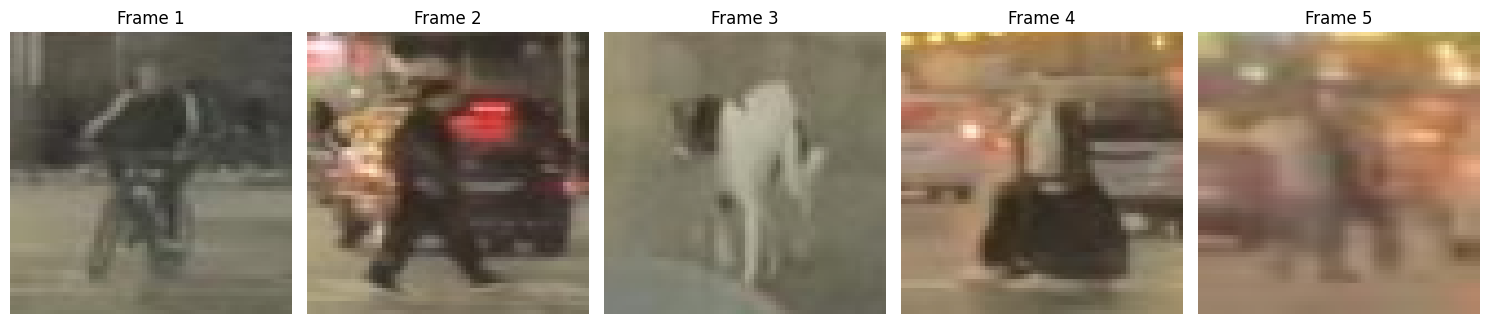

In [ ]:
import matplotlib.pyplot as plt

# Function to display a sequence of frames
def visualize_sequence(stacked_sequences, sequence_idx, sequence_length=10):
    sequence = stacked_sequences[sequence_idx]

    fig, axes = plt.subplots(1, sequence_length, figsize=(15, 5))

    for i, ax in enumerate(axes):
        if i < len(sequence):
            # Ensure that each frame is in RGB format (use RGB format for visualization)
            ax.imshow(sequence[i])
            ax.axis('off')
            ax.set_title(f"Frame {i + 1}")
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# To visualize a specific sequence (for example, the first sequence)
visualize_sequence(features, sequence_idx=0, sequence_length=5)


# Train  BI LRCN
TimeDistributed CNN + Bi-LSTM (i.e., an LRCN model with a bidirectional LSTM), which is a great choice for spatiotemporal data like video frames or sequential image data.



In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.layers import Conv2D, TimeDistributed
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Constants
SEQUENCE_LENGTH = 5  # or any desired sequence length
IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64
CLASSES_LIST = {
    0: 'walking',
    1: 'walking group',
    2: 'standing',
    3: 'crossing'
}

def create_LRCN_model():
    '''
    This function will construct the required LRCN model with Bi-LSTM.
    Returns:
        model: The constructed LRCN model.
    '''

    # We will use a Sequential model for model construction.
    model = Sequential()

    # Define the Model Architecture.
    ########################################################################################################################

    # TimeDistributed wrapper for 2D Convolution
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'),
                              input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    # Flatten the convolutional output
    model.add(TimeDistributed(Flatten()))

    # Use Bi-LSTM instead of LSTM
    model.add(Bidirectional(LSTM(32)))  # Bidirectional LSTM for sequence learning

    # Final output layer (softmax for classification)
    model.add(Dense(len(CLASSES_LIST), activation='softmax'))

    ########################################################################################################################

    # Display the models summary.
    model.summary()

    # Return the constructed LRCN model.
    return model


In [ ]:
# Construct the required LRCN model.
LRCN_model = create_LRCN_model() # Display the success message. print("Model Created Successfully!")

  super().__init__(**kwargs)



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_84             │ (None, 5, 64, 64, 16)  │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_85             │ (None, 5, 16, 16, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_86             │ (None, 5, 16, 16, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_87             │ (None, 5, 16, 16, 32)  │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_88             │ (None, 5, 4, 4, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_89             │ (None, 5, 4, 4, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_90             │ (None, 5, 4, 4, 64)    │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_91             │ (None, 5, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_92             │ (None, 5, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_93             │ (None, 5, 2, 2, 64)    │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_94             │ (None, 5, 1, 1, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_95             │ (None, 5, 64)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,604 (334.39 KB)

 Trainable params: 85,604 (334.39 KB)

 Non-trainable params: 0 (0.00 B)

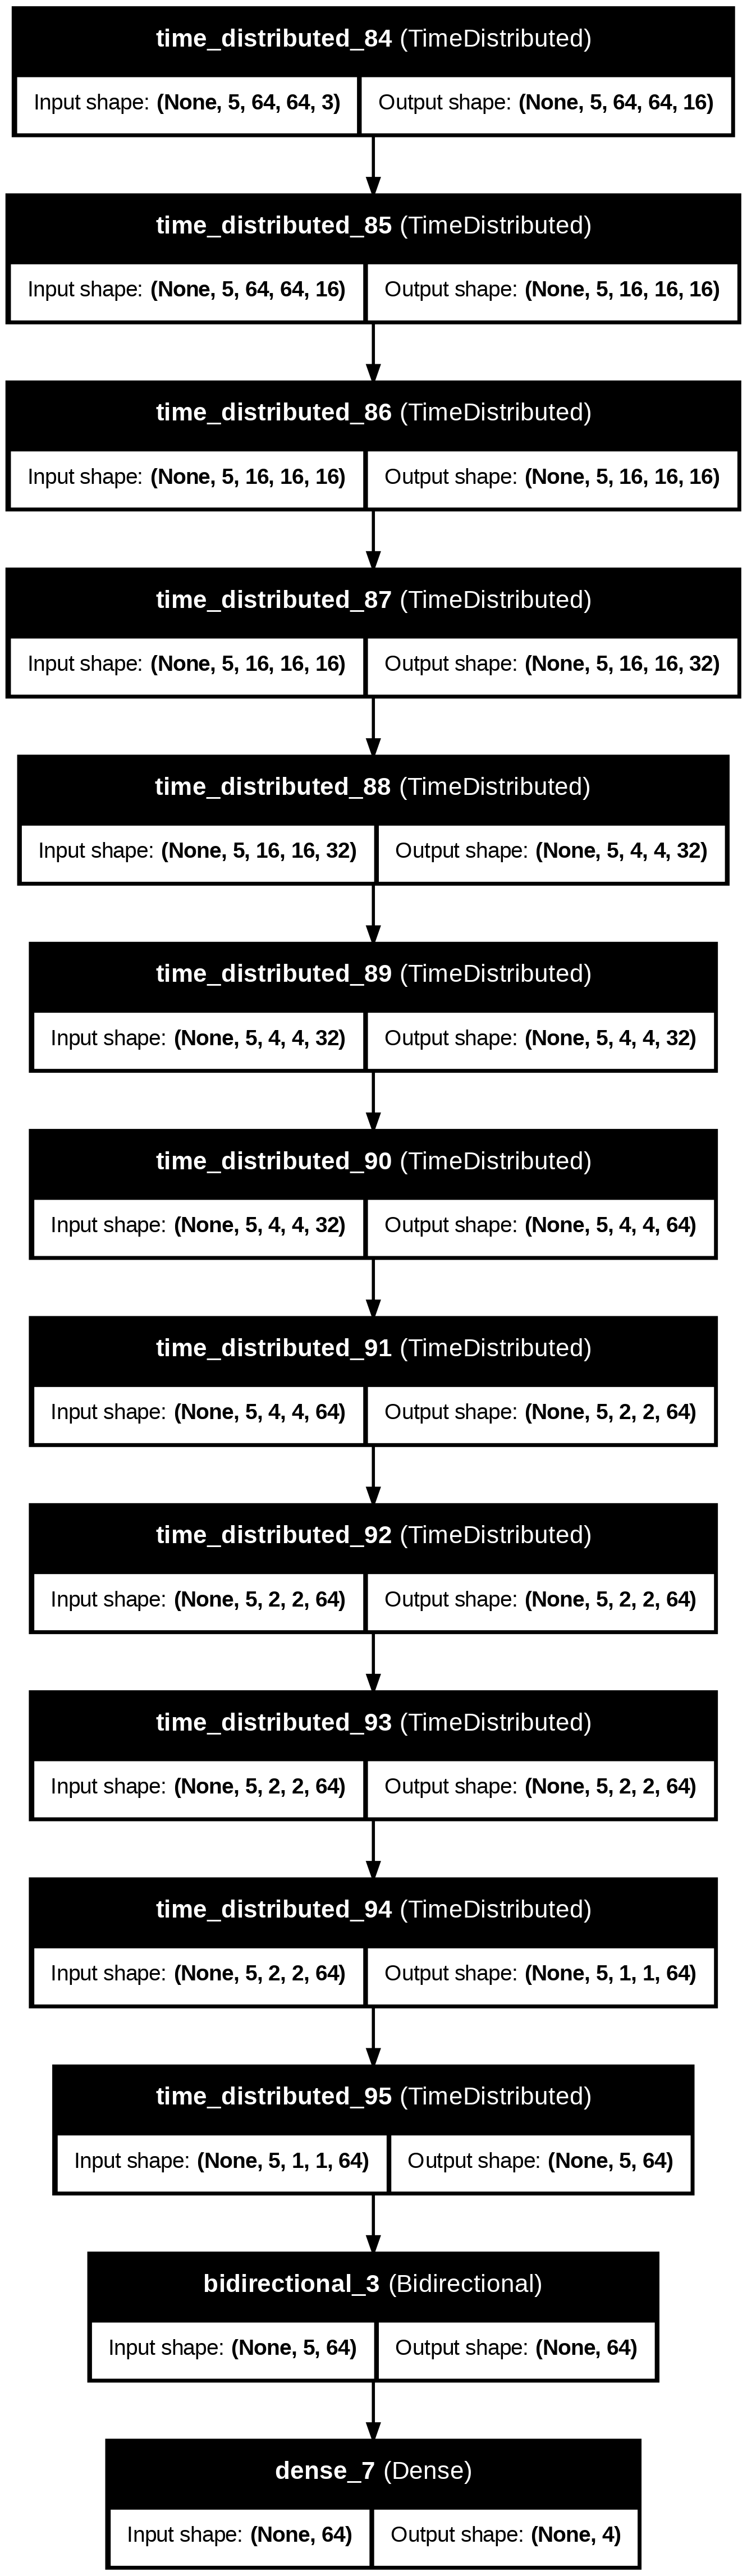

In [ ]:
# Plot the structure of the contructed LRCN model.
plot_model(LRCN_model, to_file = 'LRCN_model_structure_plot.png', show_shapes = True, show_layer_names = True)

In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalize the feature values to range [0, 1]
features = features.astype('float32') / 255.0

# One-hot encode the labels
labels = to_categorical(labels, num_classes=len(classes_list))

# Final shapes check
print(f"Features shape: {features.shape}")  # (num_samples, SEQUENCE_LENGTH, H, W, C)
print(f"Labels shape (one-hot): {labels.shape}")  # (num_samples, num_classes)


Features shape: (8, 5, 64, 64, 3)
Labels shape (one-hot): (8, 4)


In [ ]:
# Create an Instance of Early Stopping Callback.
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrics to the model.
LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model.
LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 300, batch_size = 32 , shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])



Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 482ms/step - accuracy: 0.2933 - loss: 1.3737 - val_accuracy: 0.5455 - val_loss: 1.3411
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.3112 - loss: 1.3414 - val_accuracy: 0.5455 - val_loss: 1.2777
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.3504 - loss: 1.3138 - val_accuracy: 0.5455 - val_loss: 1.2071
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.3584 - loss: 1.3062 - val_accuracy: 0.5455 - val_loss: 1.1621
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.3761 - loss: 1.3412 - val_accuracy: 0.5455 - val_loss: 1.1678
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3685 - loss: 1.3247 - val_accuracy: 0.5455 - val_loss: 1.1845
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2954 - loss: 1.3390 - val_accuracy: 0.5455 - val_loss: 1.1998
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3919 - loss: 1.2745 - val_accuracy: 0.5455 - val_

In [ ]:
# Early stopping
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=50, mode='min', restore_best_weights=True)

# Compile model with a lower learning rate
optimizer = Adam(learning_rate=1e-4)
LRCN_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Fit the model
LRCN_model_training_history = LRCN_model.fit(
    x=features_train,
    y=labels_train,
    epochs=300,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    class_weight=class_weights
)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 519ms/step - accuracy: 0.2740 - loss: 1.8004 - val_accuracy: 0.5455 - val_loss: 1.2091
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2874 - loss: 1.7058 - val_accuracy: 0.5455 - val_loss: 1.2219
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.2855 - loss: 1.7470 - val_accuracy: 0.5455 - val_loss: 1.2339
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2738 - loss: 1.6569 - val_accuracy: 0.5455 - val_loss: 1.2450
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3212 - loss: 1.6616 - val_accuracy: 0.5455 - val_loss: 1.2556
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3231 - loss: 1.5933 - val_accuracy: 0.5455 - val_loss: 1.2651
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4273 - loss: 1.5496 - val_accuracy: 0.5455 - val_loss: 1.2733
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3899 - loss: 1.5174 - val_accuracy: 0.5455 - val_

In [ ]:
# Now evaluate the model
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

# Print evaluation results
print(f"Evaluation results: {model_evaluation_history}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3843 - loss: 1.2566
Evaluation results: [1.2553569078445435, 0.3888888955116272]


In [ ]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

# Save the Model.
LRCN_model.save(model_file_name)

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    '''
    This function will plot the metrics passed to it in a graph.
    Args:
        model_training_history: A history object containing a record of training and validation
                                loss values and metrics values at successive epochs
        metric_name_1:          The name of the first metric that needs to be plotted in the graph.
        metric_name_2:          The name of the second metric that needs to be plotted in the graph.
        plot_name:              The title of the graph.
    '''

    # Get metric values using metric names as identifiers.
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Construct a range object which will be used as x-axis (horizontal plane) of the graph.
    epochs = range(len(metric_value_1))

    # Plot the Graph.
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

    # Add title to the plot.
    plt.title(str(plot_name))

    # Add legend to the plot.
    plt.legend()

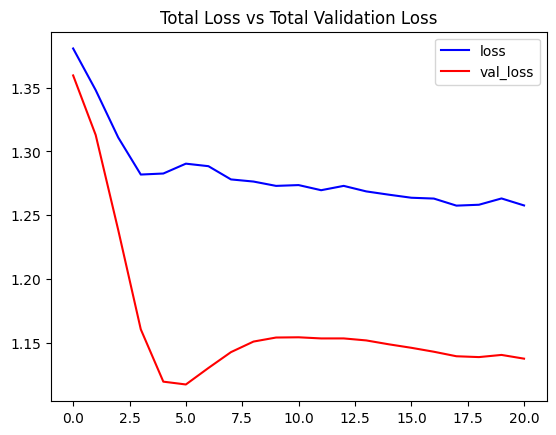

In [ ]:
# Visualize the training and validation loss metrices.
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

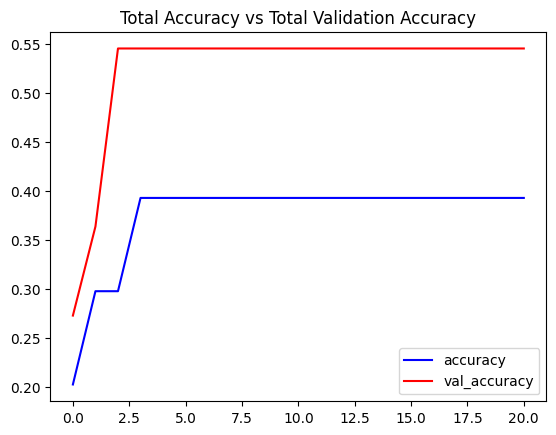

In [ ]:
# Visualize the training and validation accuracy metrices.
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

# Test the model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predict class probabilities
predictions = LRCN_model.predict(features)

# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Print shape just for debugging
print("Predicted Labels Shape:", predicted_labels.shape)
print("True Labels Shape:", labels_test.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Labels Shape: (8,)
True Labels Shape: (36, 4)


In [ ]:
print("features shape:", features.shape)

features shape: (8, 5, 64, 64, 3)


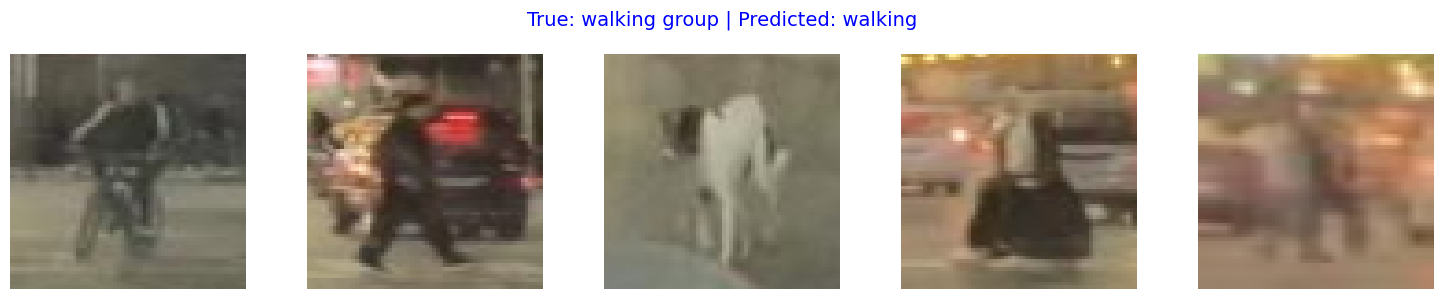

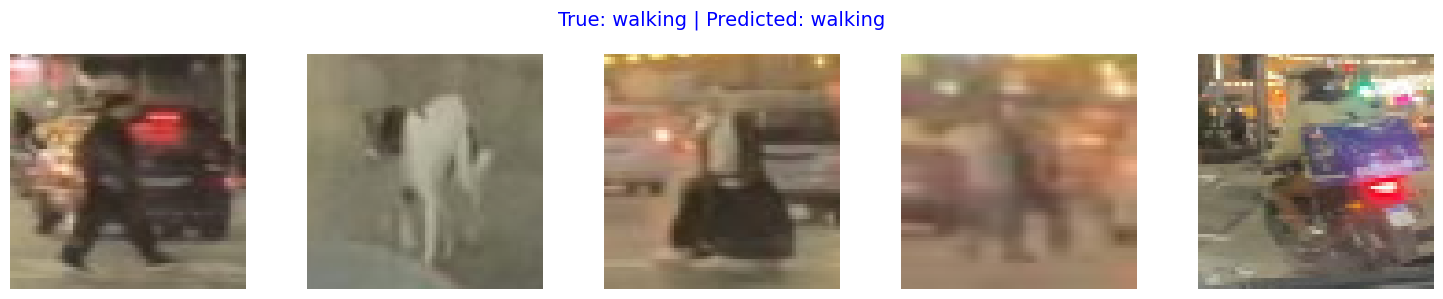

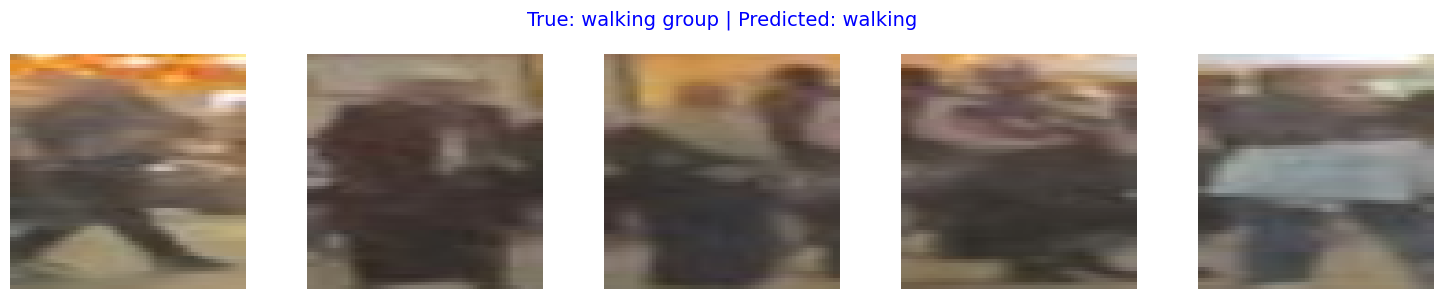

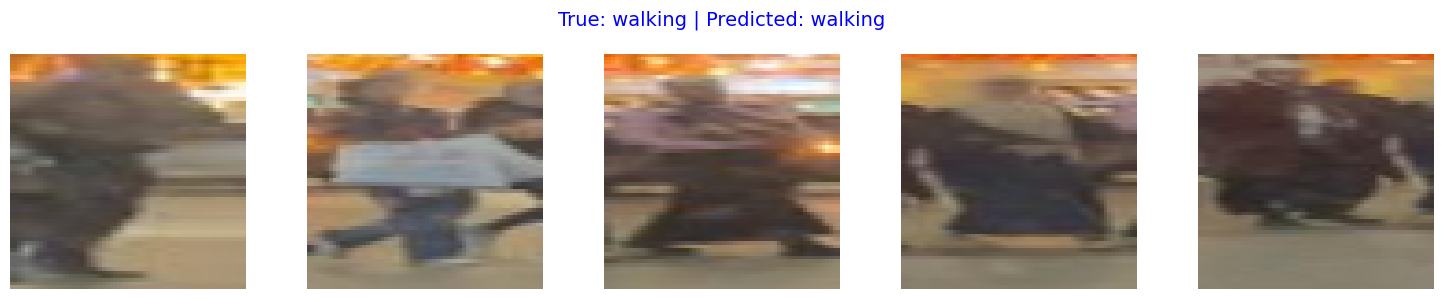

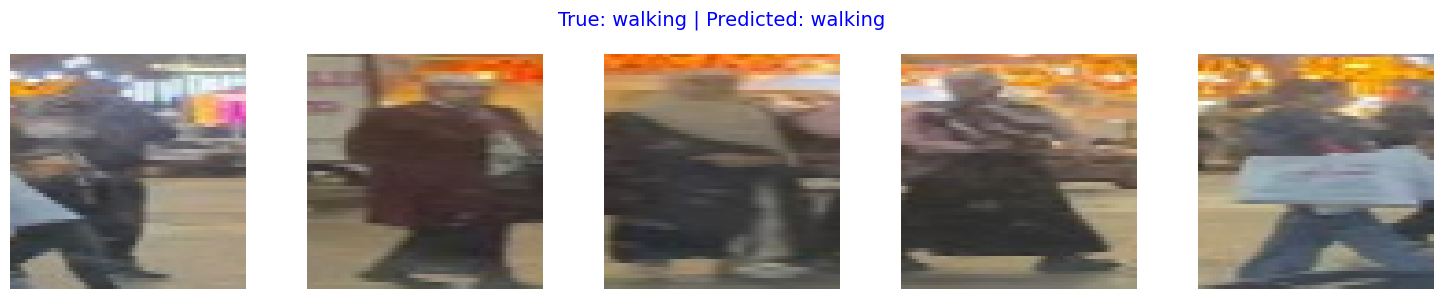

In [ ]:
# Number of samples to visualize
num_samples = 5

for i in range(num_samples):
    fig, axes = plt.subplots(1, SEQUENCE_LENGTH, figsize=(15, 3))

    # Safely convert class index to label
    true_label = classes_list[int(labels_test[i][0])] if isinstance(labels_test[i], (np.ndarray, list)) else classes_list[int(labels_test[i])]
    predicted_label = classes_list[int(predicted_labels[i][0])] if isinstance(predicted_labels[i], (np.ndarray, list)) else classes_list[int(predicted_labels[i])]

    fig.suptitle(f"True: {true_label} | Predicted: {predicted_label}", fontsize=14, color='blue')

    for j in range(SEQUENCE_LENGTH):
        frame = features[i][j]

        # Convert to uint8 if normalized
        if frame.max() <= 1.0:
            frame = (frame * 255).astype('uint8')
        else:
            frame = frame.astype('uint8')

        axes[j].imshow(frame)
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
%%capture
!pip install ultralytics==8.3.40

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
# import cv2
# import numpy as np
# from collections import deque
# from ultralytics import YOLO
# from tensorflow.keras.models import load_model
# import os



# frames_pedestrians = []

# # Load models
# yolo_model = YOLO("/content/yolo11s.pt")
# LRCN_model = load_model("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/LRCN_model___Date_Time_2025_04_13__12_09_32___Loss_1.2178815603256226___Accuracy_0.4722222089767456.h5")

# # Parameters
# input_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/Pedestrians.mov'
# output_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/predicted_output.avi'
# SEQUENCE_LENGTH = 20
# CLASSES_LIST = ["walking", "walking group", "standing", "crossing"]
# IMAGE_SIZE = 64  # Model expects 64x64

# # Function to preprocess cropped frames
# def preprocess_frame(frame):
#     resized = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
#     normalized = resized / 255.0
#     return normalized

# # Initialize sequence buffer
# sequence = deque(maxlen=SEQUENCE_LENGTH)

# # Open video
# cap = cv2.VideoCapture(input_video_path)
# width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# fps = cap.get(cv2.CAP_PROP_FPS)

# # Save output
# fourcc = cv2.VideoWriter_fourcc(*'XVID')
# out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break

#     # Detect people with YOLOv8
#     results = yolo_model(frame)[0]

#     # Loop over each detection
#     for detection in results.boxes.data:
#         x1, y1, x2, y2, conf, cls = detection.cpu().numpy()
#         class_id = int(cls)

#         if class_id == 0:  # class_id 0 is 'person' in COCO dataset
#             x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
#             cropped = frame[y1:y2, x1:x2]
#             processed = preprocess_frame(cropped)
#             sequence.append(processed)

#             # Only predict if sequence is full
#             if len(sequence) == SEQUENCE_LENGTH:
#                 input_sequence = np.array(sequence).reshape(1, SEQUENCE_LENGTH, IMAGE_SIZE, IMAGE_SIZE, 3)
#                 prediction = LRCN_model.predict(input_sequence)
#                 predicted_class = np.argmax(prediction)
#                 predicted_label = CLASSES_LIST[predicted_class]

#                 # Draw bounding box & prediction
#                 cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
#                 cv2.putText(frame, predicted_label, (x1, y1 - 10),
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

#     # Write to video
#     out.write(frame)
#     frames_pedestrians.append(frame)

# # Release
# cap.release()
# out.release()
# print("Prediction video saved successfully.")



0: 384x640 7 persons, 1 bicycle, 6 cars, 1 motorcycle, 5 traffic lights, 1 dog, 1 backpack, 327.5ms
Speed: 4.0ms preprocess, 327.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 bicycle, 5 cars, 2 motorcycles, 6 traffic lights, 1 dog, 297.9ms
Speed: 3.9ms preprocess, 297.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 bicycle, 6 cars, 2 motorcycles, 4 traffic lights, 1 dog, 304.0ms
Speed: 3.7ms preprocess, 304.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

0: 384x640 9 persons, 1 bicycle, 5 cars, 2 motorcycles, 3 traffic lights, 1 dog, 312.2ms
Speed: 6.8ms preprocess, 312.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━

In [ ]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO
from tensorflow.keras.models import load_model
import os

frames_pedestrians = []

# Load models
yolo_model = YOLO("/content/yolo11s.pt")
LRCN_model = load_model("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/LRCN_model___Date_Time_2025_04_13__12_09_32___Loss_1.2178815603256226___Accuracy_0.4722222089767456.h5")

# Parameters
input_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 2/Pedestrians.mov'
output_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/predicted_output.avi'
SEQUENCE_LENGTH = 20
CLASSES_LIST = ["walking", "walking group", "standing", "crossing"]
IMAGE_SIZE = 64

# LRCN class colors
PREDICTION_COLORS = {
    "walking": (0, 255, 0),         # Green
    "walking group": (0, 255, 255), # Yellow
    "standing": (0, 0, 255),        # Blue
    "crossing": (0, 0, 128),        # Red
}

# Animal class IDs in COCO dataset
ANIMAL_CLASS_IDS = list(range(15, 24))  # cat to elephant

# Sequence buffer
sequence = deque(maxlen=SEQUENCE_LENGTH)

# Open video
cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Output video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = yolo_model(frame)[0]

    for detection in results.boxes.data:
        x1, y1, x2, y2, conf, cls = detection.cpu().numpy()
        class_id = int(cls)
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        if class_id == 0:  # Person
            cropped = frame[y1:y2, x1:x2]
            processed = cv2.resize(cropped, (IMAGE_SIZE, IMAGE_SIZE)) / 255.0
            sequence.append(processed)

            if len(sequence) == SEQUENCE_LENGTH:
                input_seq = np.array(sequence).reshape(1, SEQUENCE_LENGTH, IMAGE_SIZE, IMAGE_SIZE, 3)
                prediction = LRCN_model.predict(input_seq, verbose=0)
                predicted_class = np.argmax(prediction)
                predicted_label = CLASSES_LIST[predicted_class]
                color = PREDICTION_COLORS[predicted_label]

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, predicted_label, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        elif class_id in ANIMAL_CLASS_IDS:
            # Just draw animal boxes in purple
            cv2.rectangle(frame, (x1, y1), (x2, y2), (128, 0, 128), 2)
            cv2.putText(frame, "Animal", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (128, 0, 128), 2)

    out.write(frame)
    frames_pedestrians.append(frame)

cap.release()
out.release()
print("Prediction video saved successfully.")



0: 384x640 7 persons, 1 bicycle, 6 cars, 1 motorcycle, 5 traffic lights, 1 dog, 1 backpack, 299.8ms
Speed: 4.7ms preprocess, 299.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 bicycle, 5 cars, 2 motorcycles, 6 traffic lights, 1 dog, 302.2ms
Speed: 3.6ms preprocess, 302.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 bicycle, 6 cars, 2 motorcycles, 4 traffic lights, 1 dog, 305.5ms
Speed: 4.0ms preprocess, 305.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 bicycle, 5 cars, 2 motorcycles, 3 traffic lights, 1 dog, 305.9ms
Speed: 8.2ms preprocess, 305.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 bicycle, 7 cars, 1 motorcycle, 4 traffic lights, 1 dog, 1 backpack, 477.4ms
Speed: 4.1ms preprocess, 477.4ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 1 bicycle, 8 c